# Downloading packages -------------------------------------------------------
- Downloading fmsb from CRAN ...                OK [393.1 Kb in 0.9s]
Successfully downloaded 1 package in 2.4 seconds.

The following package(s) will be installed:
- fmsb    [0.7.6]
- scales  [1.4.0]
- stringr [1.5.1]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing fmsb ...                           OK [installed binary and cached in 2.5s]
- Installing scales ...                         OK [linked from cache]
- Installing stringr ...                        OK [linked from cache]


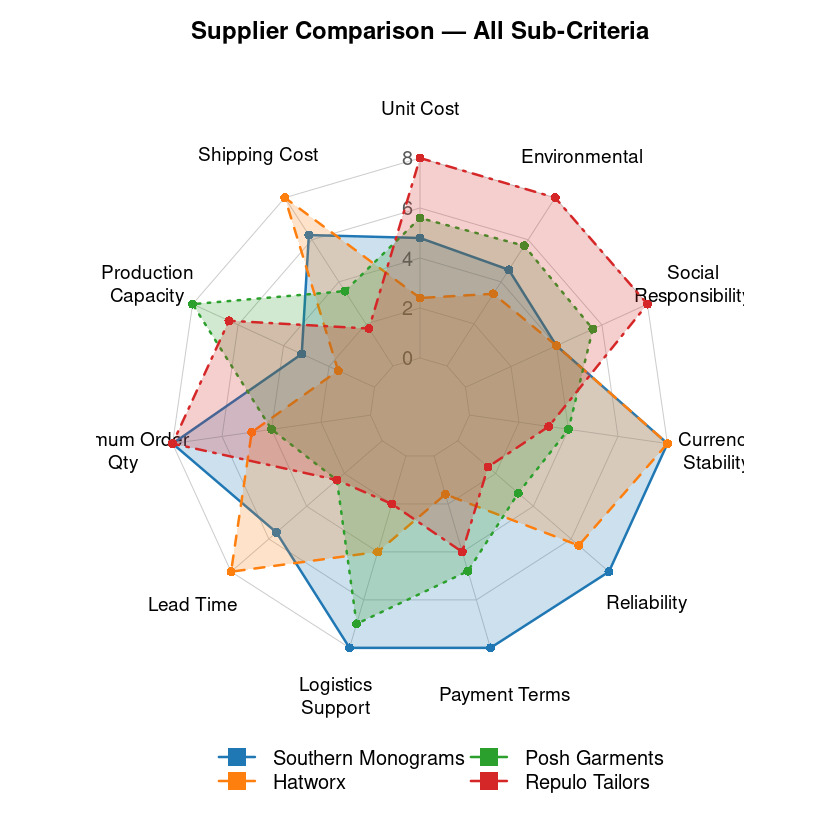

In [5]:
 install.packages(c("fmsb","scales","stringr"))  
library(fmsb)
library(scales)
library(stringr)

# --- suppliers (order = polygons) ---
suppliers <- c("Southern Monograms","Hatworx","Posh Garments","Repulo Tailors")

# --- your sub-criteria “wgt” vectors (bigger = better) ---
wgt <- list(
  "Unit Cost"             = c(6, 3, 7,10),
  "Shipping Cost"         = c(7, 9, 4, 2),
  "Production Capacity"   = c(4, 2,10, 8),
  "Minimum Order Qty"     = c(10,6, 5,10),
  "Lead Time"             = c(7,10, 3, 3),
  "Logistics Support"     = c(8, 4, 7, 2),
  "Payment Terms"         = c(10,2, 6, 5),
  "Reliability"           = c(10,8, 4, 2),
  "Currency Stability"        = c(10,10,5, 4),
  "Social Responsibility" = c(5, 5, 7,10),
  "Environmental"         = c(4, 3, 5, 7)
)

# --- build scores 0–10 per sub-criterion (keeps your relative judgements) ---
scale_to_10 <- function(x) 10 * (as.numeric(x) / max(as.numeric(x)))
score_mat <- sapply(wgt, scale_to_10)                       # cols = subcriteria
rownames(score_mat) <- suppliers
score_df <- as.data.frame(score_mat, check.names = FALSE)

# pretty, wrapped axis labels (max ~14 chars/line)
axis_labels <- str_wrap(colnames(score_df), width = 14)

# --- fmsb input: first two rows must be max/min ---
plot_df <- rbind(rep(10, ncol(score_df)),
                 rep( 0, ncol(score_df)),
                 score_df)
plot_df <- as.data.frame(lapply(plot_df, as.numeric))
row.names(plot_df) <- c("MAX","MIN", rownames(score_df))

# --- style ---
cols  <- c("#1f77b4","#ff7f0e","#2ca02c","#d62728")
fills <- alpha(cols, 0.22)

# margin with extra space at top for the legend
op <- par(mar = c(3.5, 4, 2.5, 4))   # bottom, left, top, right

radarchart(
  plot_df,
  axistype   = 1,
  pcol       = cols,
  pfcol      = fills,
  plwd       = 2,
  cglcol     = "grey80", cglty = 1, cglwd = 0.8,
  axislabcol = "grey35", caxislabels = c("0","2","4","6","8","10"),
  vlabels    = axis_labels,
  vlcex      = 0.95,
  title      = "Supplier Comparison — All Sub-Criteria"
)

# legend in the margin, centered, two columns
par(xpd = NA)                                  # allow drawing in margins
legend(
  x = 0.2, y = -1.3,                           # center-top
  legend = rownames(score_df),
  col    = cols, pt.bg = fills,
  pch    = 15, lwd = 2, pt.cex = 2,
  bty    = "n", cex = 1.0,
  horiz  = FALSE, ncol = 2, xjust = 0.5        # <<< two columns
)
par(xpd = FALSE)
par(op)  

In [6]:
# Save to PNG
png("supplier_comparison.png", width = 1200, height = 900, res = 150)  # res=150 for sharpness

op <- par(mar = c(3.5, 4, 2.5, 4))   # bottom, left, top, right

radarchart(
  plot_df,
  axistype   = 1,
  pcol       = cols,
  pfcol      = fills,
  plwd       = 2,
  cglcol     = "grey80", cglty = 1, cglwd = 0.8,
  axislabcol = "grey35", caxislabels = c("0","2","4","6","8","10"),
  vlabels    = axis_labels,
  vlcex      = 0.95,
  title      = "Supplier Comparison — All Sub-Criteria"
)

par(xpd = NA)  
legend(
  x = 0.2, y = -1.3,
  legend = rownames(score_df),
  col    = cols, pt.bg = fills,
  pch    = 15, lwd = 2, pt.cex = 2,
  bty    = "n", cex = 1.0,
  horiz  = FALSE, ncol = 2, xjust = 0.5
)
par(xpd = FALSE)
par(op)

dev.off()  # close PNG device


pdf 
  2